# Training

Agregamos la carpeta padre al Path para poder importar el módulo `cowaver`:

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

## Funciones de graficado

In [2]:
import io
import torch
import torchaudio
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt
import cowaver
from cowaver.utils import AUDIO_SAMPLE_RATE
from cowaver.models import TrainHistory, TestResults

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

def graficar_waveform(waveform, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")
        should_show = True
    else:
        should_show = False

    if waveform.dim() == 2:
        waveform = waveform[0]

    waveform = waveform.detach().cpu()
    time = torch.arange(len(waveform)) / AUDIO_SAMPLE_RATE

    ax.plot(time.numpy(), waveform.numpy())
    ax.set_title("Forma de onda")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")
    ax.grid(True)

    if should_show:
        plt.show()

def graficar_mel(mel, ax=None, should_show: bool = False):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3), layout="constrained")

    if mel.dim() == 4:
        mel = mel[0, 0]       # [B,1,mel_bins,T]
    elif mel.dim() == 3:
        mel = mel[0]          # [B,mel_bins,T] o [1,mel_bins,T]
    elif mel.dim() != 2:
        raise ValueError(f"Unexpected mel shape: {mel.shape}")

    mel = torch.expm1(mel).clamp_min(0)
    mel = mel.detach().cpu()

    ax.imshow(
        mel.numpy(),
        cmap="coolwarm",
        aspect="auto",
        origin="lower", interpolation="nearest"
    )

    ax.set_title("Mel Spectrogram")
    ax.set_xlabel("Time Frame")
    ax.set_ylabel("Mel-bin Index")
    ax.set_xticks([0, mel.size(1) - 1])
    ax.set_yticks([0, mel.size(0) - 1])

    if should_show:
        plt.show()

def graficar_train_history(train_history: TrainHistory, subfig=None, should_show: bool = True):
    if subfig is None:
        _, ax = plt.subplots(figsize=(8, 3), layout="constrained")
    else:
        ax = subfig.subplots()
    epochs = range(1, train_history.num_epochs + 1)
    ax.plot(epochs, train_history.train_losses, label="Train")
    ax.plot(epochs, train_history.val_losses, "r", label="Validation")
    ax.set_title("Train vs Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()
    if should_show:
        plt.show()

In [3]:
from pathlib import Path
from cowaver.utils import encontrar_dispositivo

DEVICE = encontrar_dispositivo()
DATASET_SIZE = 480

# Idioma, puede ser "french" o "spanish"
LANGUAGE = "spanish"

cross_language_results = {}
cross_language_results[LANGUAGE] = {}

# Rutas a los datos
workspace_path = Path("../") / LANGUAGE
compressed_phones_path = workspace_path / f"kalulu-phones-{DATASET_SIZE}.tar.xz"
compressed_spoken_path = workspace_path / f"kalulu-spoken-{DATASET_SIZE}.tar.xz"

print(f"Buscando {compressed_phones_path}", end="... ")
print("OK" if compressed_phones_path.exists() else "ERROR")

print(f"Buscando {compressed_spoken_path}", end="... ")
print("OK" if compressed_spoken_path.exists() else "ERROR")

# Carpeta donde se descomprimirán los datos
data_path = workspace_path / "data"

# Carpeta donde se guardan los checkpoints
checkpoints_path = workspace_path / "checkpoints" / str(DATASET_SIZE)

Buscando dispositivo... MPS
Buscando ../spanish/kalulu-phones-480.tar.xz... OK
Buscando ../spanish/kalulu-spoken-480.tar.xz... OK


In [4]:
from cowaver.utils import descomprimir_archivo, listar_clases, separar_clases

phones_path = descomprimir_archivo(compressed_phones_path, data_path)
spoken_path = descomprimir_archivo(compressed_spoken_path, data_path)

palabras = listar_clases(phones_path / "train")

print("Total de palabras:", len(palabras))

palabras_a_entrenar, palabras_a_generalizar = separar_clases(palabras, fraction=0.2)
print("Palabras a entrenar:", len(palabras_a_entrenar))
print(f"Palabras a generalizar ({len(palabras_a_generalizar)}):", palabras_a_generalizar)

Descomprimiendo ../spanish/kalulu-phones-480.tar.xz en ../spanish/data/kalulu-phones-480... OK
Descomprimiendo ../spanish/kalulu-spoken-480.tar.xz en ../spanish/data/kalulu-spoken-480... OK
Total de palabras: 480
Palabras a entrenar: 384
Palabras a generalizar (96): ['abierto', 'adulto', 'aire', 'alta', 'alumno', 'ama', 'ancho', 'artista', 'atleta', 'azúcar', 'bandera', 'calle', 'calor', 'cero', 'cerro', 'cohete', 'con', 'copa', 'cruzar', 'culpa', 'dado', 'dama', 'dejar', 'doce', 'enseña', 'era', 'esquina', 'fama', 'faro', 'feliz', 'fino', 'fruta', 'gracias', 'grande', 'helado', 'himno', 'idea', 'jugar', 'lava', 'lengua', 'limpio', 'los', 'luchar', 'magia', 'mancha', 'manga', 'marzo', 'medida', 'mes', 'miedo', 'modelo', 'moneda', 'montaña', 'mágico', 'música', 'niños', 'novios', 'nube', 'nudo', 'nueve', 'nuevo', 'octubre', 'oficina', 'ojo', 'parque', 'paseo', 'persona', 'pie', 'piel', 'pino', 'pintor', 'pintura', 'plana', 'planta', 'pluma', 'ratones', 'raíz', 'reino', 'rojo', 'roto', '

In [7]:
from cowaver.datamodules import TinyPairedMel
from cowaver.utils import extraer_waveform

paired_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras)
test_set = paired_data.test_set

@widgets.interact(idx=(0, len(test_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = test_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 4), layout="constrained")
        fig.suptitle(test_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        plt.show()

    display(widgets.VBox([out, widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform)])]))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

In [5]:
import torch
from torch import nn
from torch.optim import AdamW, Optimizer
from torch.optim.lr_scheduler import LRScheduler, LinearLR

import cowaver
from cowaver.modules.autoencoders import ConvAutoEncoder
from cowaver.models import DataModule, TestResults, TrainProgramme, TrainableMixin
from cowaver.utils import distancia_mel
    
class TrainableConvAutoEncoder(TrainableMixin, ConvAutoEncoder):
    def __init__(self, seq_len: int = 49, mel_bins: int = 80):
        super().__init__(x_dim=(1, seq_len, mel_bins), h_dim=256, n_filters=32, filter_size=5)
        self.seq_len = seq_len
        self.mel_bins = mel_bins

    @property
    def name(self) -> str:
        return f"autoencoder_sl{self.seq_len}_mb{self.mel_bins}"

    def training_step(self, batch, batch_idx, phase: int):
        (x, y), labels, task_ids = batch
        B = x.size(0)
        y = y.transpose(2, 3)
        y_hat = self(y)
        return nn.functional.mse_loss(y_hat.reshape(B, -1), target=y.reshape(B, -1))

    def test_step(self, data: DataModule, batch: tuple) -> TestResults:
        (x, y), targets, task_ids = batch
        y = y.transpose(2, 3)
        y_hat = self(y)
        y_hat = y_hat.squeeze(1).transpose(1, 2)
        
        prototypes = data.mel_prototypes(y_hat.device)

        distances = distancia_mel(y_hat, prototypes)

        k = min(5, distances.size(1))
        topk = distances.topk(k, dim=1, largest=False).indices

        targets = targets.view(-1, 1)

        top1 = (topk[:, :1] == targets).any(dim=1).sum().item()
        top3 = (topk[:, :min(3, k)] == targets).any(dim=1).sum().item()
        top5 = (topk[:, :k] == targets).any(dim=1).sum().item()

        return TestResults(top1=top1, top3=top3, top5=top5)

    def optimizer(self, phase: int, programme: TrainProgramme) -> Optimizer:
        trainable_params = filter(lambda p: p.requires_grad, self.parameters())
        return AdamW(params=trainable_params, lr=programme.epsilon_zero, weight_decay=1e-4)

    def scheduler(self, optimizer: Optimizer, phase: int, programme: TrainProgramme) -> LRScheduler:
        return LinearLR(optimizer, start_factor=1.0, end_factor=programme.end_factor, total_iters=programme.decay_epochs())

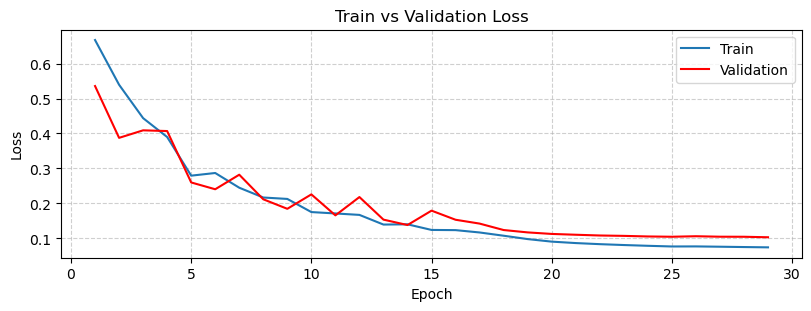

In [8]:
from cowaver.checkpoints import cargar_checkpoint

net = TrainableConvAutoEncoder()
train_history = cargar_checkpoint(net, folder=checkpoints_path / "spoken", silent=True)
train_history.train_losses = train_history.train_losses[1:]
train_history.val_losses = train_history.val_losses[1:]
graficar_train_history(train_history)

In [10]:
from cowaver.utils import evaluar_red

test_results = evaluar_red(net, paired_data)

ValueError: not enough values to unpack (expected 3, got 2)